In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob
from tqdm import tqdm
import cv2
import copy

from mmdet.apis import init_detector
from libs.datasets.pipelines import Compose
from libs.datasets.metrics.culane_metric import interp
from libs.utils.visualizer import visualize_lanes

/home/docker/.pyenv/versions/3.10.13/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


reading list...: 100%|██████████| 7029/7029 [00:00<00:00, 607295.41it/s]


random index:  4394


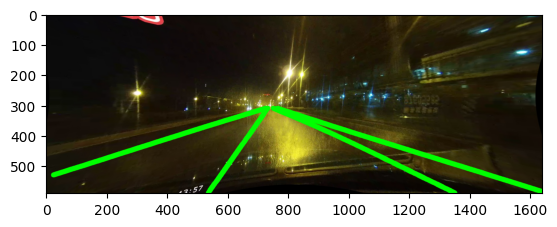

In [114]:
dataset_root = '/work/dataset/CULane'
test_split = os.path.join(dataset_root, 'list/test_split/test8_night.txt')

def read_datapair(path):
    with open(path, 'r') as fr:
        files = fr.readlines()
    files = [file.strip() for file in files]
    annos = []
    for file in tqdm(files, desc="reading list..."):
        path_tokens = file.split('/')
        fname_tokens = path_tokens[-1].split('.')
        filename = fname_tokens[0]
        ext = fname_tokens[1]
        anno_ext = 'lines.txt'
        path_tokens[-1] = filename + '.' + anno_ext
        anno_path = '/'.join(path_tokens)
        annos.append(anno_path)

    return files, annos

test_files, test_annos = read_datapair(test_split)

def draw_lane(lane, img=None, img_shape=None, width=30, color=(255, 255, 255)):
    """
    Overlay lanes on the image.
    Args:
        lane (np.ndarray): N (x, y) coordinates from a single lane, shape (N, 2).
        img (np.ndarray): Source image.
        img_shape (tuple): Blank image shape used when img is None.
        width (int): Lane thickness.
        color (tuple): Lane color in BGR.
    Returns:
        img (np.ndarray): Output image.
    """
    if img is None:
        img = np.zeros(img_shape, dtype=np.uint8)
    lane = lane.astype(np.int32)
    for p1, p2 in zip(lane[:-1], lane[1:]):
        cv2.line(img, tuple(p1), tuple(p2), color, thickness=width)
    return img

ridx = np.random.randint(0, len(test_files))
print("random index: ", ridx)
example_file = test_files[ridx]
example_anno = test_annos[ridx]

def visualize(img_path, anno_path):
    img = cv2.imread(img_path)
    with open(anno_path, 'r') as fr:
        anno = fr.readlines()
    anno = [coor.strip() for coor in anno]
    lanes = []
    for line in anno:
        coordinate = []
        coor_tokens = line.split(' ')
        x = coor_tokens[0::2] # x coordinates
        y = coor_tokens[1::2] # y coordinates
        assert len(x) == len(y), "number of x coordinates must be same as number of y coordinates!"

        for xy in zip(x, y):
            if float(xy[0]) < 0:
                continue
            coordinate.append([float(xy[0]), float(xy[1])])
        lanes.append(coordinate)

    for lane in lanes:
        lane = np.array(lane)
        img = draw_lane(lane, img, img_shape=img.shape, width=15, color=(0, 255, 0))

    # cv2.imshow('vis', img)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)

visualize(os.path.join(dataset_root, example_file), os.path.join(dataset_root, example_anno))



In [42]:
txt = 'driver_100_30frame/05251548_0439.MP4/04920.jpg'
path_tokens = txt.split('/')
fname_tokens = path_tokens[-1].split('.')
filename = fname_tokens[0]
ext = fname_tokens[1]
anno_ext = 'lines.txt'
path_tokens[-1] = filename + '.' + anno_ext
anno_path = '/'.join(path_tokens)
print(anno_path)

with open(os.path.join(dataset_root, anno_path)) as fr:
    anno = fr.readlines()
anno = [coor.strip() for coor in anno]
lanes = []
for line in anno:
    coordinate = []
    coor_tokens = line.split(' ')
    x = coor_tokens[0::2] # x coordinates
    y = coor_tokens[1::2] # y coordinates
    assert len(x) == len(y), "number of x coordinates must be same as number of y coordinates!"

    for xy in zip(x, y):
        coordinate.append(list(xy))
    lanes.append(coordinate)

img = cv2.imread(os.path.join(dataset_root, txt))
img.shape


driver_100_30frame/05251548_0439.MP4/04920.lines.txt


(590, 1640, 3)